# Smarter mechanism selection

Combinatoric generators (RMG and similar) build mechanisms by applying reaction families across composition space, then prune with rate-rule thresholds. They tend to produce mechanisms that are too large and full of irrelevant steps, because relevance is decided *after* enumeration. With a differentiable solver and an exact sensitivity (the degree of rate control) we can decide relevance *during* selection. This notebook recovers a minimal mechanism from an over-complete candidate set three independent ways: a flux + rate-control screen, a best-subgraph search against data, and a symbolic rate law.

In [1]:
%matplotlib inline

## An over-complete candidate mechanism

The true CO oxidation mechanism is three Langmuir-Hinshelwood steps. The candidate set adds four decoys a generator would also propose: an Eley-Rideal step, a redundant route through a bound `OCO*` intermediate, and a water spectator. All four carry negligible flux.

In [2]:
import numpy as np
import discopt.mkm as mk
from discopt.mkm.examples import overcomplete_co_oxidation, co_oxidation

m, _ = overcomplete_co_oxidation(500.0)
for r in m.reactions:
    print(('  decoy ' if r.name.startswith('[decoy]') else '  real  '), r.equation())
print(f'\n{len(m.reactions)} candidate steps, of which 3 are real')

  real   CO + Pt <=> CO*
  real   O2 + 2 Pt <=> 2 O*
  real   CO* + O* <=> CO2 + 2 Pt
  decoy  CO + O* -> CO2 + Pt
  decoy  CO* + O* -> OCO* + Pt
  decoy  OCO* -> CO2 + Pt
  decoy  H2O + Pt <=> H2O*

7 candidate steps, of which 3 are real


## Synthetic turnover data

Generate the turnover frequency of CO2 from the *true* three-step mechanism at several gas compositions. This is the data the selection must reproduce.

In [3]:
CONDS = [{'CO': 1.0, 'O2': 0.5}, {'CO': 2.0, 'O2': 0.5}, {'CO': 0.5, 'O2': 1.0}, {'CO': 1.0, 'O2': 2.0}]
mt, _ = co_oxidation(500.0)
CO, O2, CO2 = (mt._by_name[n] for n in ('CO', 'O2', 'CO2'))
data = [mk.solve_steady_state(mt, mk.DifferentialReactor({CO: c['CO'], O2: c['O2'], CO2: 0.0})
        ).production_rate(CO2) for c in CONDS]
for c, d in zip(CONDS, data):
    print(f"  CO={c['CO']}, O2={c['O2']}:  TOF = {d:.4f}")

  CO=1.0, O2=0.5:  TOF = 1.1902
  CO=2.0, O2=0.5:  TOF = 0.9460
  CO=0.5, O2=1.0:  TOF = 1.3044
  CO=1.0, O2=2.0:  TOF = 1.5702


## Method 1 -- flux screen ranked by degree of rate control

`reduce_by_drc` drops steps that carry negligible flux (removing a zero-flux step provably cannot change the steady state) and ranks the survivors by the exact Campbell degree of rate control.

In [4]:
res = mk.reduce_by_drc(m, CONDS, 'CO2')
print('kept   :', res.kept)
print('dropped:', res.dropped)
print(f'turnover reproduced to {res.max_tof_error:.1e} relative error\n')
print('normalized max flux   degree of rate control   step')
for r in m.reactions:
    drc = res.drc.get(r.name)
    drc_s = f'{drc:+.3f}' if drc is not None else '   -- '
    print(f'   {res.flux[r.name]:8.1e}            {drc_s}          {r.name}')

kept   : ['CO adsorption', 'O2 dissociation', 'surface reaction']
dropped: ['[decoy] Eley-Rideal', '[decoy] OCO* formation', '[decoy] OCO* decomposition', '[decoy] water adsorption']
turnover reproduced to 6.7e-12 relative error

normalized max flux   degree of rate control   step
    1.0e+00            +0.000          CO adsorption
    5.0e-01            +0.003          O2 dissociation
    1.0e+00            +1.000          surface reaction
    1.7e-13               --           [decoy] Eley-Rideal
    8.2e-12               --           [decoy] OCO* formation
    8.2e-12               --           [decoy] OCO* decomposition
    0.0e+00               --           [decoy] water adsorption


The decoys sit at ~1e-13 of the dominant flux and fall away; among the retained steps the surface reaction carries essentially all of the rate control (it is rate-determining).

## Method 2 -- best-subgraph selection against the data

`select_subgraph` searches over which steps to keep and scores each candidate sub-mechanism by an exact numerical steady-state solve, returning the fewest steps that still reproduce the turnover data.

In [5]:
sel = mk.select_subgraph(m, CONDS, 'CO2', data, engine='greedy')
print('selected:', sel.selected)
print(f'steps = {sel.n_steps},  misfit = {sel.misfit:.1e}')

selected: ['CO adsorption', 'O2 dissociation', 'surface reaction']
steps = 3,  misfit = 9.8e-32


Sweeping the whole accuracy-versus-size front shows *why* three is the answer: the misfit only collapses once all three real steps are present, and adding decoys buys nothing. The knee is the mechanism to keep.

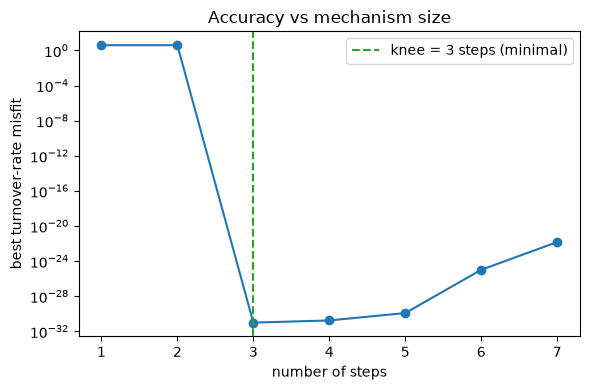

In [6]:
front = mk.pareto_subgraph(m, CONDS, 'CO2', data)
ks = sorted(front)
misfits = [max(front[k][0], 1e-32) for k in ks]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(ks, misfits, 'o-')
knee = min(k for k in ks if front[k][0] < 1e-6)
ax.axvline(knee, color='C2', ls='--', label=f'knee = {knee} steps (minimal)')
ax.set_xlabel('number of steps'); ax.set_ylabel('best turnover-rate misfit')
ax.set_title('Accuracy vs mechanism size'); ax.legend(); fig.tight_layout()


### The same selection as a true MILP

Embedding the *nonlinear* steady state (coverages, bilinear rates) in a mixed-integer program is intractable. But moving to **flux space** makes it a clean MILP that discopt solves in a fraction of a second: the steady-state balances on the net rates of progress are linear, a binary gates each step, and a capacity bound (a flux cannot exceed its rate constant) rejects the kinetically incapable decoy routes -- even the Eley-Rideal shortcut, which is *fewer* steps but whose rate constant is far too small to carry the observed flux. Minimizing the number of steps recovers the minimal mechanism.

In [7]:
import time
t = time.time()
milp = mk.select_subgraph(m, CONDS, 'CO2', data, engine='milp')
print(f'MILP solved in {time.time()-t:.2f} s  (status: {milp.status})')
print('selected:', milp.selected)

MILP solved in 0.24 s  (status: optimal)
selected: ['CO adsorption', 'O2 dissociation', 'surface reaction']


## Method 3 -- a compact symbolic rate law

Instead of selecting elementary steps, regress an interpretable closed-form rate from a small library of mechanistic templates (power law, dual-site Langmuir-Hinshelwood), chosen by AIC.

In [8]:
grid = [{'CO': co, 'O2': o2} for co in (0.5, 1.0, 2.0) for o2 in (0.5, 1.0, 2.0)]
ydata = [mk.solve_steady_state(mt, mk.DifferentialReactor({CO: c['CO'], O2: c['O2'], CO2: 0.0})
         ).production_rate(CO2) for c in grid]
law = mk.fit_rate_law(grid, ydata, ['CO', 'O2'])
print('winning template :', law.template)
print('rate law         :', law.expression)
print('apparent orders  :', law.orders)
print('AIC by template  :', [(n, round(a, 1)) for n, a in law.candidates])

winning template : power_law
rate law         : P_O2**0.19*k/P_CO**0.04
apparent orders  : {'CO': -0.039, 'O2': 0.191}
AIC by template  : [('power_law', -36.5), ('langmuir_hinshelwood', -8.8)]


The fitted law is CO-inhibited (negative apparent CO order at high coverage) and positive order in O2 -- the classic Langmuir-Hinshelwood signature, consistent with the apparent orders the full model would give.

## Takeaways

- **All three methods agree** on the minimal three-step mechanism, from three different signals: flux + exact rate control, data-misfit + parsimony, and a parsimony-scored rate law.
- Relevance is decided by **exact sensitivity and global search**, not enumerate-then-threshold, so irrelevant steps are removed with a guarantee (zero flux cannot change the steady state) rather than a heuristic cutoff.
- The selection can be posed for a global solver two ways. In **coverage space** it is a nonlinear MINLP (`engine='minlp'`) that is intractable beyond a few steps. In **flux space** it is a true **MILP** (`engine='milp'`) that discopt solves in a fraction of a second, because the steady-state balances are linear there and a rate-constant capacity bound rejects kinetically incapable routes. The right restriction turns an intractable problem into an easy one.